<div style="text-align: justify;">

# Mastering the Fundamentals: A Guide to OpenDSS-LV Modeling

## Objectives

This notebook is a guide to modeling a low-voltage (LV) distribution network
and running a power flow, the foundational skill every Part 4 chapter builds
on. By the end you will be able to:

- Model an LV network in OpenDSS: transformers, lines, and loads.
- Run a power flow and read the result back out as a pandas DataFrame.
- Recognize where the wrapper stops and the raw OpenDSS engine underneath is
  still one call away.

It runs through [`ark.dss`](../../ark/dss/), a small pythonic wrapper this
project built over [OpenDSSDirect.py](https://github.com/dss-extensions/OpenDSSDirect.py).
OpenDSSDirect.py was chosen specifically because it installs and runs
identically on macOS, Linux, and Windows, no external OpenDSS install, no
Windows-only COM binding required.

</div>

<div style="text-align: justify;">

To learn how to model an LV network in Python, we will first build the
simple network shown below: a transformer (11kV/0.4kV), a three-phase line
connecting bus A with bus B, and three single-phase lines connecting bus B
with buses C, D, and E. Buses C, D, and E represent the connection points of
three different houses.

- The 11kV and 0.4kV are line-to-line nominal values, so the single-phase
  houses have a nominal line-to-neutral value of 230V.

<center><img style="float: middle;" src="Figure_1.png" width="40%"></center>
<center>Figure 1. Simple LV Network</center>

</div>

<div style="text-align: justify;">

## 1. Building the circuit

`Circuit` is a thin, pythonic handle on OpenDSSDirect.py's engine. Every
`circuit.command(...)` call below sends one line of native OpenDSS script,
exactly like the `dss.text(...)` calls in the original tutorial this notebook
is based on; only the wrapper around it changed.

</div>

In [ ]:
from ark.dss.circuit import Circuit

circuit = Circuit()
print("Backed by OpenDSSDirect.py, no external OpenDSS install needed on any OS")

Backed by OpenDSSDirect.py, no external OpenDSS install needed on any OS


<div style="text-align: justify;">

### 1.1 Creating a circuit

1. **`Clear`** clears any existing model.
2. **`Set DefaultBaseFrequency=50`** sets the circuit's frequency to 50Hz.
3. **`New Circuit.Simple_LV_Network`** creates a new circuit named
   "Simple_LV_Network".
4. **`Edit vsource.source ...`** edits the source bus (OpenDSS's name for the
   slack bus) and sets its parameters.

<font color='red'>**Note:**</font> Do not change the order of these
commands nor any of the parameters.

</div>

In [ ]:
circuit.command("Clear")
circuit.command("Set DefaultBaseFrequency=50")
circuit.command("New Circuit.Simple_LV_Network")
circuit.command("Edit vsource.source bus1=sourceBus basekv=11 pu=1.0 phases=3")

''

<div style="text-align: justify;">

### 1.2 Adding the 11kV/0.4kV transformer

- **`New Transformer.LVTR`** creates a new transformer named LVTR.
- **`Buses=[sourceBus, A.1.2.3]`** sets the two buses it connects:
  **sourceBus** and bus **A**.
- **`Conns=[delta wye]`** sets a delta-wye connection.
- **`KVs=[11, 0.4]`** sets the transformer ratio, 11kV to 0.4kV.
- **`KVAs=[250 250]`** sets the rated capacity, 250kVA.
- **`%Rs=0.00`**, **`Xhl=2.5`**, **`%loadloss=0`** set the series resistance,
  reactance, and rated-power loss percentage.

</div>

In [ ]:
circuit.command(
    "New transformer.LVTR Buses=[sourcebus, A.1.2.3] Conns=[delta wye] "
    "KVs=[11, 0.4] KVAs=[250 250] %Rs=0.00 xhl=2.5 %loadloss=0"
)

''

<div style="text-align: justify;">

### 1.3 Creating linecodes

When multiple lines share the same conductor characteristics, we define a
**linecode** once and reuse it. `linecode.240sq` describes a three-phase
segment with 240mm² conductors; `linecode.16sq` describes a single-phase
segment with 16mm² conductors.

</div>

In [ ]:
circuit.command("new linecode.240sq nphases=3 R1=0.127 X1=0.072 R0=0.342 X0=0.089 units=km")
circuit.command("new linecode.16sq nphases=1 R1=1.15 X1=0.083 R0=1.2 X0=0.083 units=km")

''

<div style="text-align: justify;">

### 1.4 Creating the 400V and 230V lines

One three-phase line connects bus A and bus B; three single-phase lines
connect B to C, D, and E respectively.

</div>

In [ ]:
circuit.command("new line.A_B bus1=A.1.2.3 bus2=B.1.2.3 length=1 phases=3 units=km linecode=240sq")
circuit.command("new line.B_L1 bus1=B.1 bus2=C.1 length=0.01 phases=1 units=km linecode=16sq")
circuit.command("new line.B_L2 bus1=B.2 bus2=D.1 length=0.01 phases=1 units=km linecode=16sq")
circuit.command("new line.B_L3 bus1=B.3 bus2=E.1 length=0.01 phases=1 units=km linecode=16sq")

''

<div style="text-align: justify;">

### 1.5 Connecting loads to a bus

Each single-phase load represents one house:

- <font color='red'>Red house</font> (bus C) is Load_1, on phase 1.
- <font color='blue'>Blue house</font> (bus D) is Load_2, on phase 2.
- <font color='limegreen'>Green house</font> (bus E) is Load_3, on phase 3.

| Load Name | Phases | Connected bus | Peak Demand (kW) | PF |
|:---------:|:------:|:-------------:|:-----------------:|:--:|
| Load_1 | 1 | C | 7 | 0.95 |
| Load_2 | 1 | D | 6 | 0.95 |
| Load_3 | 1 | E | 8 | 0.95 |

`kV=(0.4 3 sqrt /)` is Reverse Polish Notation for the single-phase
line-to-neutral voltage, 230V. `model=1` is a constant P+jQ load model.
`Vminpu`/`Vmaxpu` bound the voltage range the load model is valid for; do
not change those two. `status=fixed` means this load's `kW` is exactly what
we set it to, it does not respond to a global `LoadMult` (worth remembering
for the loading-level analysis in the exercises below). For different
demands, change `kW` and `pf`.

</div>

In [ ]:
circuit.command(
    "new load.Load_1 bus1=C.1 phases=1 kV=(0.4 3 sqrt /) kW=7 pf=0.95 "
    "model=1 conn=wye Vminpu=0.85 Vmaxpu=1.20 status=fixed"
)
circuit.command(
    "new load.Load_2 bus1=D.1 phases=1 kV=(0.4 3 sqrt /) kW=6 pf=0.95 "
    "model=1 conn=wye Vminpu=0.85 Vmaxpu=1.20 status=fixed"
)
circuit.command(
    "new load.Load_3 bus1=E.1 phases=1 kV=(0.4 3 sqrt /) kW=8 pf=0.95 "
    "model=1 conn=wye Vminpu=0.85 Vmaxpu=1.20 status=fixed"
)

''

<div style="text-align: justify;">

### 1.6 Control mode and voltage bases

We are not controlling network elements (e.g. on-load tap changers) or
running a time series, so `controlmode` and `mode` are set to **static** and
**snapshot**: a single power flow run. `Set VoltageBases` and
`calcvoltagebases` are what let OpenDSS report voltages in per unit.

</div>

In [ ]:
circuit.command("set controlmode=static")
circuit.command("set mode=snapshot")
circuit.command("Set VoltageBases=[11 0.4]")
circuit.command("calcvoltagebases")

''

<div style="text-align: justify;">

### 1.7 Solving the power flow

If the solve fails, OpenDSS raises an exception naming exactly which command
caused it, usually a modeling error above, not a wrapper bug.

</div>

In [ ]:
circuit.solve()
if circuit.converged:
    print("The circuit was solved successfully")

The circuit was solved successfully


<div style="text-align: justify;">

## 2. Reading circuit properties

This is where the wrapper earns its keep. `circuit.lines`, `circuit.loads`,
and `circuit.transformers` are plain Python iterators over small dataclasses,
no manual `First()`/`Next()` bookkeeping and no shared "active element"
pointer to keep track of.

</div>

In [ ]:
for line in circuit.lines:
    print(line)

Line(name='a_b', bus1='a.1.2.3', bus2='b.1.2.3', phases=3, length=1.0)
Line(name='b_l1', bus1='b.1', bus2='c.1', phases=1, length=0.01)
Line(name='b_l2', bus1='b.2', bus2='d.1', phases=1, length=0.01)
Line(name='b_l3', bus1='b.3', bus2='e.1', phases=1, length=0.01)


In [ ]:
first_line = next(circuit.lines)
print(
    f"Line {first_line.name} connected between buses "
    f"({first_line.bus1}, {first_line.bus2}) has a length of {first_line.length} km"
)

Line a_b connected between buses (a.1.2.3, b.1.2.3) has a length of 1.0 km


<div style="text-align: justify;">

`Load` objects expose the properties a book chapter actually needs
(`kw`, `kvar`, `pf`, `phases`, `bus1`) directly as attributes, no property
lookup dance required.

</div>

In [ ]:
first_load = next(circuit.loads)
print(f"Power factor of {first_load.name} is {first_load.pf}")

Power factor of load_1 is 0.95


<div style="text-align: justify;">

For anything `Circuit`'s dataclasses don't model yet, `circuit.command`
is the same escape hatch OpenDSS scripting always offers: query any element
property directly by name.

</div>

In [ ]:
print(circuit.command("? line.a_b.length"))

1


<div style="text-align: justify;">

### Loop through elements

Iterating is just iterating. Combining it with `circuit.line_losses()` (a
tidy DataFrame, see below) replaces what used to be a manual
`First()`/`Next()` loop building up two parallel dicts by hand.

</div>

In [ ]:
line_lengths = {line.name: line.length for line in circuit.lines}
line_losses_kw = circuit.line_losses().set_index("line")["p_loss_kw"].to_dict()

print(line_lengths)
print(line_losses_kw)

{'a_b': 1.0, 'b_l1': 0.01, 'b_l2': 0.01, 'b_l3': 0.01}
{'a_b': 0.41718508492699036, 'b_l1': 0.012266686069033313, 'b_l2': 0.008896571764394139, 'b_l3': 0.01617004814549182}


<div style="text-align: justify;">

## 3. Extracting results

Once the circuit is solved, `Circuit`'s result methods turn OpenDSS's raw
per-conductor output into tidy, long-format DataFrames: one row per
(element, phase), ready to facet or color by `phase` directly in `ark.plot`.

### Load active (P) and reactive (Q) power

</div>

In [ ]:
circuit.element_powers("loads")

,name,phase,p_kw,q_kvar
0,load_1,1,6.999709,2.300433
1,load_2,1,6.000045,1.972135
2,load_3,1,7.999260,2.629204


<div style="text-align: justify;">

### Active (P) and reactive (Q) power of a three-phase element

`element_powers` works the same way for any wrapped element type, here the
transformer, one row per phase rather than a flat list of P/Q pairs to index
into by hand.

</div>

In [ ]:
circuit.element_powers("transformers")

,name,phase,p_kw,q_kvar
0,lvtr,1,6.508937,2.526754
1,lvtr,2,7.359244,1.775980
2,lvtr,3,7.584264,2.887739


<div style="text-align: justify;">

### Transformer currents

Per-phase current isn't wrapped in `Circuit` yet (no chapter has needed it
as a DataFrame), so this is a good spot to use the `circuit.dss` escape
hatch: the full native OpenDSSDirect.py API, unwrapped, one property away.

</div>

In [ ]:
circuit.dss.Transformers.First()
currents = circuit.dss.CktElement.CurrentsMagAng()
i1, i2, i3 = currents[0], currents[2], currents[4]

print(f"Current of the transformer {circuit.dss.CktElement.Name()}:")
print(f"phase 1 current = {abs(i1):.3f} A")
print(f"phase 2 current = {abs(i2):.3f} A")
print(f"phase 3 current = {abs(i3):.3f} A")

Current of the transformer Transformer.lvtr:
phase 1 current = 1.099 A
phase 2 current = 1.192 A
phase 3 current = 1.278 A


<div style="text-align: justify;">

### Bus voltages

`bus_voltages()` returns every bus's per-phase voltage in one DataFrame; no
more setting an "active bus" and reading a flat magnitude/angle array back
out by index.

</div>

In [ ]:
voltages = circuit.bus_voltages()
voltages.head()

,bus,phase,vmag_pu,vangle_deg,kv_base
0,sourcebus,1,0.999994,-0.000490,6.350853
1,sourcebus,2,0.999995,-120.000577,6.350853
2,sourcebus,3,0.999993,119.999428,6.350853
3,a,1,0.999271,-30.123428,0.230940
4,a,2,0.999387,-150.105326,0.230940


In [ ]:
load = next(circuit.loads)
bus = load.bus1.split(".")[0]
house_voltage = voltages.query("bus == @bus")["vmag_pu"].iloc[0]
print(f"The voltage at the bus connected to {load.name} is {house_voltage:.3f} pu")

The voltage at the bus connected to load_1 is 0.977 pu


<div style="text-align: justify;">

The same DataFrame answers the three-phase case for free: filter to
one bus and every phase's magnitude and angle is right there as rows,
instead of indexing into a flat array at 0, 2, 4.

</div>

In [ ]:
voltages.query("bus == 'a'")

,bus,phase,vmag_pu,vangle_deg,kv_base
3,a,1,0.999271,-30.123428,0.23094
4,a,2,0.999387,-150.105326,0.23094
5,a,3,0.999174,89.858102,0.23094


<div style="text-align: justify;">

### Line losses

`circuit.summary()` is the one-line health check every notebook's first
solved cell wants: convergence, element counts, and total circuit losses
together.

Worth capturing this network's peak-loading loss in a plain variable here,
not just printing it: OpenDSSDirect.py is a singleton engine (see
`ark/dss/circuit.py`'s own docstring), so every `Circuit` object, this one
included, is a thin handle onto the *same* global state. Once the exercises
below `Clear` and rebuild a different network, `circuit.summary()` stops
describing Figure 1, it starts describing whatever was solved most
recently, silently. A plain float captured now survives that; a live
`circuit` reference does not.

</div>

In [ ]:
summary = circuit.summary()
base_peak_loss_kw = summary["total_p_loss_kw"]
print(f"Active power (P) losses = {summary['total_p_loss_kw']:.3f} kW")
print(f"Reactive power (Q) losses = {summary['total_q_loss_kvar']:.3f} kvar")
summary

Active power (P) losses = 0.455 kW
Reactive power (Q) losses = 0.289 kvar


{'converged': True,
 'n_buses': 6,
 'n_lines': 4,
 'n_loads': 3,
 'n_transformers': 1,
 'total_p_loss_kw': 0.45451839090595514,
 'total_q_loss_kvar': 0.28880128735383254}

<div style="text-align: justify;">

## 4. Visualizing the network

A bus-voltage table answers "what is the voltage," a network diagram
answers "where." Both matter for the same reason: a violation only makes
sense once you can see how far it is from the source. `Circuit.lines`
already gives every bus-to-bus connection; the only missing piece is a
layout to draw it with.

There's no bus coordinate data in this model (`Buscoords.dss` is a SMART-DS
thing, not something a hand-built tutorial circuit has), so
`topology_layout` computes one: a breadth-first search out from the source
bus, one layer per hop, centered so each layer reads as a row. It is not
geographically accurate, this is a schematic, not a GIS map, but it is
enough to see how a violation at one bus relates to its neighbors.

This diagram uses matplotlib rather than Lets-Plot (the library every other
chart in this book uses, including the voltage-compliance charts later in
this notebook), for one specific reason: Lets-Plot has no per-point image
marker (`geom_raster` is a continuous field, not a scatter of small
icons, and `geom_point`'s `shape` aesthetic only offers built-in shapes
like circle/square/triangle, not arbitrary pictures). Matplotlib does, via
its font manager, and this book's own site already ships an icon set worth
reusing: [Bootstrap Icons](https://icons.getbootstrap.com/), MIT licensed,
the same one behind the `bi bi-github`/`bi-envelope-at-fill` icons in this
book's own page footer. `ark.plot.icons` vendors that font (converted once
from `.woff` to `.ttf`, matplotlib's FreeType can't open `.woff` directly)
so a diagram can draw a real house/sun/lightning-bolt glyph at each bus, in
brand colors, with no new runtime dependency, matplotlib and the one-time
conversion tool were already project dependencies.

`bus_pairs`, `topology_layout`, `bus_roles`, and `plot_topology` are plain
functions, not part of `ark.dss` yet: this is their first use, and per this
project's own notebook-first-then-promote discipline, they only get
promoted into the shared package once a second Part 4 notebook actually
needs them too. `ark.plot.icons` and `ark.plot.tokens` are shared already,
general-purpose infrastructure any future diagram can reuse, not specific
to OpenDSS. `ark.plot.matplot_theme.configure_matplotlib_style()` applies
the same brand fonts/colors/line-weights every other matplotlib figure in
this book uses; it only touches ordinary text and line rcParams, so it
doesn't affect the icon glyphs, `icon_font()` sets their font family
explicitly regardless of what `configure_matplotlib_style()` sets
globally.

The legend is a real `ax.legend()`, not a second, independent set of
hand-placed `ax.text()` calls at hardcoded axes-fraction coordinates (an
earlier version did this, and every position had to be tuned by hand). A
small `_IconHandler` teaches `ax.legend()` how to draw a Bootstrap Icon
glyph as a swatch, matplotlib's own legend layout does the rest, which
means it inherits its frame/font-size/spacing from
`configure_matplotlib_style()`'s rcParams too.

`plot_topology(..., orientation="horizontal")` grows the tree left-to-right
instead of top-to-bottom, worth reaching for on a wide, shallow feeder
where a tall vertical figure wastes space. Depth spacing and sibling
spacing just swap which axis they're on (see `topology_layout`); nothing
else about the function changes.

</div>

In [ ]:
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
import matplotlib.text as mtext

from ark.plot.icons import ICONS, icon_font
from ark.plot.matplot_theme import configure_matplotlib_style
from ark.plot.tokens import DANGER, PRIMARY, SUCCESS, TEXT_MUTED, WARNING

configure_matplotlib_style()


def bus_pairs(circuit: Circuit) -> tuple[list[tuple[str, str]], list[tuple[str, str]]]:
    """(line bus-pairs, transformer bus-pairs), kept separate so transformers can be drawn differently.

    `Circuit`'s dataclasses don't carry transformer bus names yet (no
    chapter has needed them as data, only as the `circuit.dss` escape hatch
    example in Section 3), so transformers are walked the same way here:
    directly through the raw OpenDSSDirect.py collection.
    """
    line_pairs = [(line.bus1.split(".")[0], line.bus2.split(".")[0]) for line in circuit.lines]

    transformer_pairs = []
    transformers = circuit.dss.Transformers
    if transformers.First():
        while True:
            bus_names = circuit.dss.CktElement.BusNames()
            transformer_pairs.append((bus_names[0].split(".")[0], bus_names[1].split(".")[0]))
            if not transformers.Next():
                break
    return line_pairs, transformer_pairs


def topology_layout(circuit: Circuit, root: str, orientation: str = "vertical") -> dict[str, tuple[float, float]]:
    """Lay out every bus in `circuit` by BFS hop-distance from `root`.

    Depth (BFS distance from `root`) sets the position along the tree's
    growth axis; buses at the same depth are spread evenly along the
    cross axis, in the order they were first reached. `orientation`
    swaps which axis is which: `"vertical"` (default) grows top-to-bottom
    (depth on y, spread on x), `"horizontal"` grows left-to-right (depth
    on x, spread on y). Good enough for a small radial LV feeder, not a
    general graph layout: buses reachable by more than one path (a looped
    or meshed network) just take whichever path BFS visits first.
    """
    line_pairs, transformer_pairs = bus_pairs(circuit)
    adjacency: dict[str, list[str]] = {}
    for bus1, bus2 in line_pairs + transformer_pairs:
        adjacency.setdefault(bus1, []).append(bus2)
        adjacency.setdefault(bus2, []).append(bus1)

    depth = {root: 0}
    queue = [root]
    while queue:
        bus = queue.pop(0)
        for neighbor in adjacency.get(bus, []):
            if neighbor not in depth:
                depth[neighbor] = depth[bus] + 1
                queue.append(neighbor)

    buses_by_depth: dict[int, list[str]] = {}
    for bus, d in depth.items():
        buses_by_depth.setdefault(d, []).append(bus)

    # Labels are always placed below a node (see plot_topology), which
    # relies on the axis "below" points along having generous spacing.
    # That's the depth axis in vertical mode (rows 2.0 apart) but the
    # cross axis in horizontal mode (siblings stacked on y), so the cross
    # spacing widens to match when horizontal, otherwise a label would
    # collide with the next sibling down.
    cross_spacing = 1.6 if orientation == "horizontal" else 1.0

    coords: dict[str, tuple[float, float]] = {}
    for d, buses in buses_by_depth.items():
        offset = (len(buses) - 1) / 2
        depth_position = float(d) * 2.0
        for i, bus in enumerate(buses):
            cross_position = (i - offset) * cross_spacing
            if orientation == "horizontal":
                coords[bus] = (depth_position, cross_position)
            else:
                coords[bus] = (cross_position, -depth_position)
    return coords


def bus_roles(circuit: Circuit, root: str) -> dict[str, str]:
    """Classify each bus as 'source', 'load', 'pv', 'load_pv', or (unlisted) a plain junction."""
    roles = {root: "source"}
    for load in circuit.loads:
        roles[load.bus1.split(".")[0]] = "load"

    pv_systems = circuit.dss.PVsystems
    if pv_systems.First():
        while True:
            bus = circuit.dss.CktElement.BusNames()[0].split(".")[0]
            roles[bus] = "load_pv" if roles.get(bus) == "load" else "pv"
            if not pv_systems.Next():
                break
    return roles


def voltage_status(voltage: float, low: float = 0.94, high: float = 1.10, near_margin: float = 0.02):
    """Classify a per-unit voltage against statutory limits: (status color, status label).

    A continuous color scale normalizes to whatever range the *current*
    data happens to span, which is misleading here: a healthy feeder
    sitting entirely within, say, 0.97-1.00 pu would still get painted
    end-to-end from one color to the other, even though none of it is
    anywhere near a real violation. A fixed, threshold-anchored status
    scale (green/amber/red, the same convention as the voltage-compliance
    charts later in this notebook) doesn't have that problem.
    """
    if voltage < low or voltage > high:
        return DANGER, "Violation"
    if voltage < low + near_margin or voltage > high - near_margin:
        return WARNING, "Near limit"
    return SUCCESS, "Compliant"


class _IconHandler(HandlerBase):
    """Draws a Bootstrap Icon glyph as a legend swatch.

    Matplotlib's legend has no built-in notion of a pictographic marker, so
    a plain colored dot or line handle can't stand in for the "house"/"sun"
    icons in `plot_topology`'s legend. Subclassing `HandlerBase` is the
    documented way to teach `ax.legend()` how to draw a custom swatch; once
    registered via `handler_map`, everything else about the legend (frame,
    font size, spacing) still comes from `configure_matplotlib_style()`'s
    rcParams, same as any other legend in the book.
    """

    def __init__(self, icon_name: str, color: str = PRIMARY):
        self.icon_name = icon_name
        self.color = color
        super().__init__()

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        text = mtext.Text(
            width / 2 - xdescent,
            height / 2 - ydescent,
            ICONS[self.icon_name],
            fontproperties=icon_font(fontsize * 1.15),
            color=self.color,
            ha="center",
            va="center",
        )
        text.set_transform(trans)
        return [text]


def plot_topology(
    circuit: Circuit,
    root: str = "sourcebus",
    title: str = "Network topology",
    figsize: tuple[float, float] = (7.5, 5.5),
    node_radius: float = 0.26,
    low: float = 0.94,
    high: float = 1.10,
    near_margin: float = 0.02,
    orientation: str = "vertical",
) -> plt.Figure:
    """Draw `circuit` as a schematic icon diagram: house/sun/lightning-bolt glyphs, voltage status colors.

    Every other size in the diagram (transformer/PV badges, icon glyphs,
    label spacing) is a fixed ratio of `node_radius`, so the whole figure
    scales coherently from that one knob instead of each size needing its
    own tuning. `low`/`high`/`near_margin` set the same statutory-limit
    thresholds `voltage_status` uses elsewhere in this notebook.
    `orientation` is `"vertical"` (source at top, tree grows downward, the
    default) or `"horizontal"` (source on the left, tree grows rightward,
    handy for a wide/shallow feeder where a tall figure wastes space).
    """
    coords = topology_layout(circuit, root, orientation)
    roles = bus_roles(circuit, root)
    line_pairs, transformer_pairs = bus_pairs(circuit)
    mean_voltage = circuit.bus_voltages().groupby("bus")["vmag_pu"].mean()

    transformer_radius = node_radius * 0.62
    pv_badge_radius = node_radius * 0.46
    pv_badge_offset = node_radius * 0.77
    node_icon_size = node_radius * 73
    transformer_icon_size = node_radius * 50
    pv_badge_icon_size = node_radius * 35
    label_fontsize = node_radius * 29
    label_gap = node_radius * 0.46

    fig, ax = plt.subplots(figsize=figsize)

    for bus1, bus2 in line_pairs:
        (x1, y1), (x2, y2) = coords[bus1], coords[bus2]
        ax.plot([x1, x2], [y1, y2], color=TEXT_MUTED, linewidth=1.4, zorder=1)

    for bus1, bus2 in transformer_pairs:
        (x1, y1), (x2, y2) = coords[bus1], coords[bus2]
        ax.plot([x1, x2], [y1, y2], color=TEXT_MUTED, linewidth=1.4, zorder=1)
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.add_patch(
            Circle((mx, my), transformer_radius, facecolor="white", edgecolor=TEXT_MUTED, linewidth=0.8, zorder=2)
        )
        ax.text(
            mx,
            my,
            ICONS["hdd-network-fill"],
            fontproperties=icon_font(transformer_icon_size),
            color=PRIMARY,
            ha="center",
            va="center",
            zorder=3,
        )

    # Every bus gets an icon, not just the "interesting" ones: a plain
    # junction (no load, no PV, not the source) is still a bus, drawn with
    # "record-circle-fill" (a ring around a dot) rather than left as a bare
    # colored disc, which read as an unfinished/placeholder node next to
    # the house/sun/lightning glyphs everywhere else in the diagram.
    glyph_by_role = {
        "source": "lightning-charge-fill",
        "load": "house-fill",
        "load_pv": "house-fill",
        "pv": "sun-fill",
    }
    for bus, (x, y) in coords.items():
        voltage = mean_voltage.get(bus)
        color, _ = voltage_status(voltage, low, high, near_margin) if voltage is not None else (TEXT_MUTED, None)
        role = roles.get(bus)

        ax.add_patch(Circle((x, y), node_radius, facecolor=color, edgecolor="white", linewidth=1.6, zorder=2))
        ax.text(
            x,
            y,
            ICONS[glyph_by_role.get(role, "record-circle-fill")],
            fontproperties=icon_font(node_icon_size),
            color="white",
            ha="center",
            va="center",
            zorder=3,
        )
        if role == "load_pv":
            ax.add_patch(
                Circle(
                    (x + pv_badge_offset, y + pv_badge_offset),
                    pv_badge_radius,
                    facecolor=WARNING,
                    edgecolor="white",
                    linewidth=1,
                    zorder=4,
                )
            )
            ax.text(
                x + pv_badge_offset,
                y + pv_badge_offset,
                ICONS["sun-fill"],
                fontproperties=icon_font(pv_badge_icon_size),
                color="white",
                ha="center",
                va="center",
                zorder=5,
            )

        label = f"{bus}\n{voltage:.3f} pu" if voltage is not None else bus
        ax.text(
            x,
            y - node_radius - label_gap,
            label,
            fontsize=label_fontsize,
            ha="center",
            va="top",
            color=PRIMARY,
            zorder=3,
        )

    # A real ax.legend(), not hand-placed text: it inherits frame/fontsize/
    # spacing from configure_matplotlib_style()'s rcParams, the same as
    # every other chart in the book, instead of a second, independent set
    # of hardcoded positions. Icon entries need the custom handler above;
    # status entries are plain colored dots, no custom handler needed.
    icon_entries = [
        ("lightning-charge-fill", "Grid source"),
        ("hdd-network-fill", "Transformer"),
        ("record-circle-fill", "Bus (junction)"),
        ("house-fill", "Load bus"),
        ("sun-fill", "PV system"),
    ]
    status_entries = [
        (SUCCESS, f"Compliant ({low:.2f}-{high:.2f} pu)"),
        (WARNING, "Near limit"),
        (DANGER, "Violation"),
    ]
    icon_handles = [Line2D([], []) for _ in icon_entries]
    status_handles = [
        Line2D([], [], marker="o", linestyle="", color=color, markersize=9) for color, _ in status_entries
    ]
    handler_map = {handle: _IconHandler(name) for handle, (name, _) in zip(icon_handles, icon_entries, strict=True)}

    ax.legend(
        handles=icon_handles + status_handles,
        labels=[label for _, label in icon_entries] + [label for _, label in status_entries],
        handler_map=handler_map,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0,
        handletextpad=0.8,
    )

    ax.set_title(title, fontsize=plt.rcParams["axes.titlesize"], color=PRIMARY, fontweight="bold", loc="left")
    ax.set_aspect("equal")
    ax.axis("off")
    # Padding on both axes, not just x: which axis needs the room to fit
    # node labels depends on `orientation` (see topology_layout), so a
    # fixed asymmetric pad only on x doesn't generalize to horizontal mode.
    xs = [x for x, _ in coords.values()]
    ys = [y for _, y in coords.values()]
    pad = node_radius + 0.6
    ax.set_xlim(min(xs) - pad, max(xs) + pad)
    ax.set_ylim(min(ys) - pad - label_gap - label_fontsize / 72, max(ys) + pad)
    fig.tight_layout()
    # Without this, the inline backend auto-displays every open figure at
    # cell-execution end *and* Jupyter separately reprs the returned Figure
    # object, doubling every rendered diagram. Closing it here leaves only
    # the second (correct) render.
    plt.close(fig)
    return fig

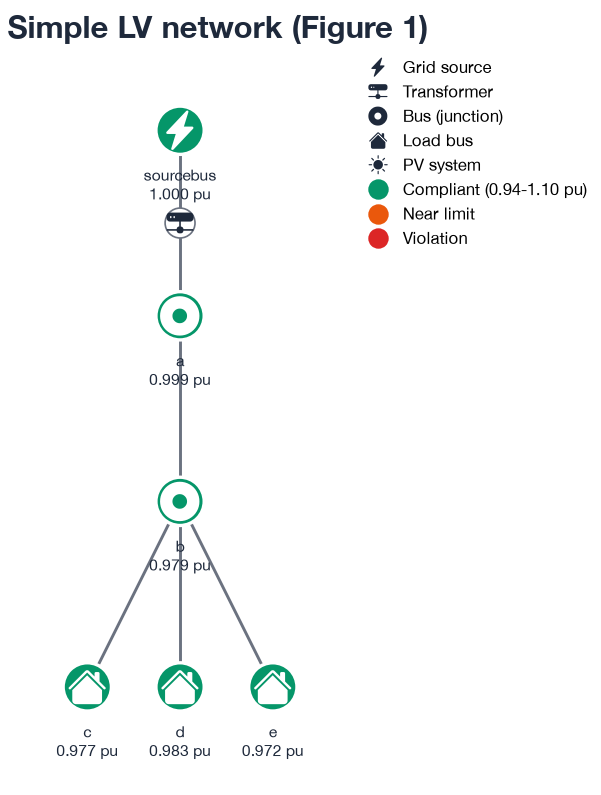

In [ ]:
plot_topology(circuit, title="Simple LV network (Figure 1)")

<div style="text-align: justify;">

### Export commands

`Circuit` wraps the result tables a chapter actually reuses. For anything
else, OpenDSS's own `export` command is still available through
`circuit.command`, the same escape hatch as above.

</div>

In [ ]:
from pathlib import Path
import tempfile

import pandas as pd


def export_to_df(circuit: Circuit, measurement: str) -> pd.DataFrame:
    with tempfile.TemporaryDirectory() as tmp:
        path = Path(tmp) / f"{measurement}.csv"
        saved_file = circuit.command(f"export {measurement} {path}")
        return pd.read_csv(saved_file, index_col=0)

In [ ]:
export_to_df(circuit, "voltages")

,BasekV,Node1,Magnitude1,Angle1,pu1,Node2,Magnitude2,Angle2,pu2,Node3,Magnitude3,Angle3,pu3
Bus,,,,,,,,,,,,,
SOURCEBUS,11.0,1,6350.810,0.0,0.99999,2,6350.820,-120.0,0.99999,3,6350.810,120.0,0.99999
A,0.4,1,230.772,-30.1,0.99927,2,230.799,-150.1,0.99939,3,230.749,89.9,0.99917
B,0.4,1,225.953,-30.5,0.97840,2,227.388,-150.3,0.98462,3,224.953,89.7,0.97407
C,0.4,1,225.588,-30.5,0.97682,0,0.000,0.0,0.00000,0,0.000,0.0,0.00000
D,0.4,1,227.077,-150.2,0.98327,0,0.000,0.0,0.00000,0,0.000,0.0,0.00000
E,0.4,1,224.533,89.7,0.97226,0,0.000,0.0,0.00000,0,0.000,0.0,0.00000


<div style="text-align: justify;">

## 5. Monitors and meters

"Monitors" and "Meters" are OpenDSS's own time-series data-collection
features, not something `Circuit` wraps (no chapter has needed a
`Circuit.monitors` API yet, the same notebook-first-then-promote discipline
the rest of `ark/` follows). They're a good last example of the escape
hatch: everything below is a direct, unwrapped `circuit.command(...)` call.

**Monitors** track specific electrical quantities (voltage, current, power,
taps, ...) at a chosen element and terminal throughout a simulation.
`Mode=0` records voltage/current, `Mode=1` records power per phase, `Mode=2`
records regulator tap changes.

**Meters** are aggregate monitors: they group elements together and total
values like losses or energy consumption, and can only be attached to
power-delivery elements (lines, transformers).

</div>

In [ ]:
# Deploy monitors before solving, to capture the time-series
circuit.command("new monitor.Vbb element=transformer.LVTR terminal=2 mode=0")
circuit.command("new monitor.SS element=transformer.LVTR terminal=1 mode=1 ppolar=no")
circuit.command("new monitor.Tap element=transformer.LVTR terminal=1 mode=2")

# Meters, to check energy exports/imports and losses
circuit.command("new energymeter.Grid element=transformer.LVTR terminal=1")
circuit.command("new energymeter.mloadB element=line.A_B terminal=2")

''

In [ ]:
circuit.solve()

<div style="text-align: justify;">

Monitors and meters only record data once told to `take` a snapshot
after a solve.

</div>

In [ ]:
circuit.command("monitor.SS.action=take")
circuit.command("monitor.Vbb.action=take")
circuit.command("monitor.Tap.action=take")
circuit.command("energymeter.Grid.action=take")
circuit.command("energymeter.mloadB.action=take")

''

In [ ]:
ss_monitor = export_to_df(circuit, "monitors SS")
ss_monitor

,t(sec),P1 (kW),Q1 (kvar),P2 (kW),Q2 (kvar),P3 (kW),Q3 (kvar),P4 (kW),Q4 (kvar)
hour,,,,,,,,,
0,0.0,6.50916,2.52712,7.36012,1.77574,7.58534,2.88837,0,0


In [ ]:
meters_monitor = export_to_df(circuit, "meters")
meters_monitor

,LDCurve,Hour,Meter,"""kWh""","""kvarh""","""Max kW""","""Max kVA""","""Zone kWh""","""Zone kvarh""","""Zone Max kW""",...,"""Aux19""","""Aux24""","""Aux29""","""11 kV Load Energy""","""Aux5""","""Aux10""","""Aux15""","""Aux20""","""Aux25""","""Aux30"""
Year,,,,,,,,,,,,,,,,,,,,,
0,,0,"""GRID""",21,7,21,23,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0,,0,"""MLOADB""",-21,-7,-21,22,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<div style="text-align: justify;">

## Do it yourself

The three exercises below build on the network above. Each has a worked
solution afterward, but it's worth attempting the exercise first: the point
is practicing `circuit.command(...)` calls and reading `Circuit`'s result
methods back, not reading someone else's answer.

</div>

<div style="text-align: justify;">

### **Exercise 1: Expanding the simple LV network**

This exercise covers two expansions. First, expand the LV network from
Figure 1 to the one shown in Figure 2 (three new houses). Second, you will
add **solar PV systems** to those new houses, as shown in Figure 3.

<center><img style="float: middle;" src="Figure_2.png" width="50%"></center>
<center>Figure 2. Expanded Simple LV Network</center>

Add the new elements below, starting from the circuit already built above:

- One **three-phase line** connecting bus **B** and bus **F**.
- Three **single-phase lines**:
  - Bus F (phase 1) and bus G: length = 0.01 km, linecode=16sq.
  - Bus F (phase 2) and bus H: length = 0.01 km, linecode=16sq.
  - Bus F (phase 3) and bus J: length = 0.01 km, linecode=16sq.
- Three **single-phase loads**: Load_4 (bus G), Load_5 (bus H), Load_6 (bus J).

| Load Name | Phases | Connected bus | Peak Demand (kW) | PF |
|:---------:|:------:|:-------------:|:-----------------:|:--:|
| Load_4 | 1 | G | 7 | 0.95 |
| Load_5 | 1 | H | 9 | 0.95 |
| Load_6 | 1 | J | 8 | 0.95 |

Annual load duration: peak 1650 hours, medium (67% of peak) 4280 hours,
minimum (33% of peak) 2830 hours.

**E1.1:** Calculate the total annual energy losses of the circuit in kWh.
Is this value different from the previous case (Figure 1)? If so, why?

**E1.2:** Extract the voltages (in pu) of all the houses for each loading
level. Considering that the upper and lower statutory voltage limits are
+10% and -6% of nominal, are those voltages compliant at all times? If not,
why?

</div>

<div style="text-align: justify;">

#### Solution

`build_expanded_lv_network` rebuilds Figure 1 from scratch, then extends it
with bus F and the three new houses, the exact same `circuit.command(...)`
calls as Section 1, just continued. Building it as a function (rather than
one long cell) is what lets Exercise 2 reuse it with an `include_pv` flag
below, instead of duplicating the whole circuit definition a second time.

</div>

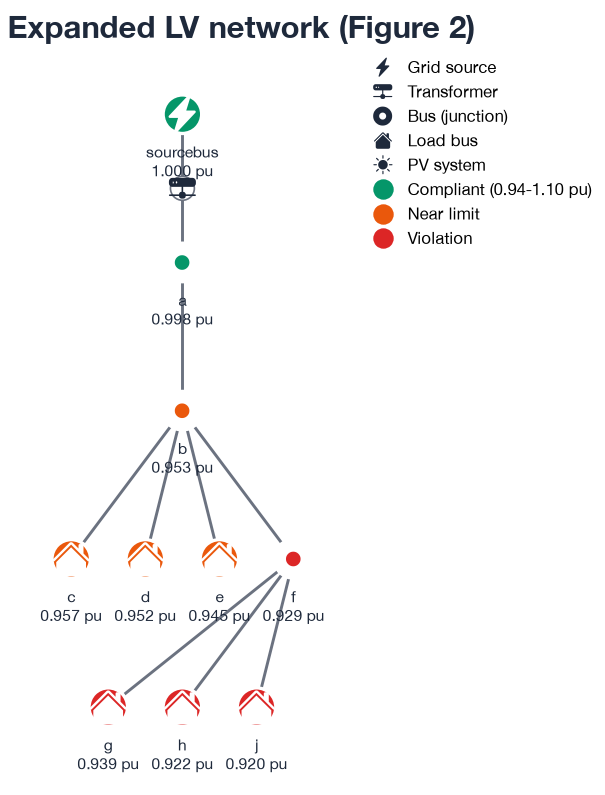

In [ ]:
def build_expanded_lv_network(include_pv: bool = False) -> Circuit:
    circuit = Circuit()
    circuit.command("Clear")
    circuit.command("Set DefaultBaseFrequency=50")
    circuit.command("New Circuit.Simple_LV_Network")
    circuit.command("Edit vsource.source bus1=sourceBus basekv=11 pu=1.0 phases=3")
    circuit.command(
        "New transformer.LVTR Buses=[sourcebus, A.1.2.3] Conns=[delta wye] "
        "KVs=[11, 0.4] KVAs=[250 250] %Rs=0.00 xhl=2.5 %loadloss=0"
    )
    circuit.command("new linecode.240sq nphases=3 R1=0.127 X1=0.072 R0=0.342 X0=0.089 units=km")
    circuit.command("new linecode.16sq nphases=1 R1=1.15 X1=0.083 R0=1.2 X0=0.083 units=km")

    circuit.command("new line.A_B bus1=A.1.2.3 bus2=B.1.2.3 length=1 phases=3 units=km linecode=240sq")
    circuit.command("new line.B_L1 bus1=B.1 bus2=C.1 length=0.01 phases=1 units=km linecode=16sq")
    circuit.command("new line.B_L2 bus1=B.2 bus2=D.1 length=0.01 phases=1 units=km linecode=16sq")
    circuit.command("new line.B_L3 bus1=B.3 bus2=E.1 length=0.01 phases=1 units=km linecode=16sq")
    circuit.command(
        "new load.Load_1 bus1=C.1 phases=1 kV=(0.4 3 sqrt /) kW=7 pf=0.95 "
        "model=1 conn=wye Vminpu=0.85 Vmaxpu=1.20 status=fixed"
    )
    circuit.command(
        "new load.Load_2 bus1=D.1 phases=1 kV=(0.4 3 sqrt /) kW=6 pf=0.95 "
        "model=1 conn=wye Vminpu=0.85 Vmaxpu=1.20 status=fixed"
    )
    circuit.command(
        "new load.Load_3 bus1=E.1 phases=1 kV=(0.4 3 sqrt /) kW=8 pf=0.95 "
        "model=1 conn=wye Vminpu=0.85 Vmaxpu=1.20 status=fixed"
    )

    # Exercise 1: bus F and three more houses, G/H/J
    circuit.command("new line.B_F bus1=B.1.2.3 bus2=F.1.2.3 length=1 phases=3 units=km linecode=240sq")
    circuit.command("new line.F_L1 bus1=F.1 bus2=G.1 length=0.01 phases=1 units=km linecode=16sq")
    circuit.command("new line.F_L2 bus1=F.2 bus2=H.1 length=0.01 phases=1 units=km linecode=16sq")
    circuit.command("new line.F_L3 bus1=F.3 bus2=J.1 length=0.01 phases=1 units=km linecode=16sq")
    circuit.command(
        "new load.Load_4 bus1=G.1 phases=1 kV=(0.4 3 sqrt /) kW=7 pf=0.95 "
        "model=1 conn=wye Vminpu=0.85 Vmaxpu=1.20 status=fixed"
    )
    circuit.command(
        "new load.Load_5 bus1=H.1 phases=1 kV=(0.4 3 sqrt /) kW=9 pf=0.95 "
        "model=1 conn=wye Vminpu=0.85 Vmaxpu=1.20 status=fixed"
    )
    circuit.command(
        "new load.Load_6 bus1=J.1 phases=1 kV=(0.4 3 sqrt /) kW=8 pf=0.95 "
        "model=1 conn=wye Vminpu=0.85 Vmaxpu=1.20 status=fixed"
    )

    if include_pv:
        # Exercise 2: PV systems on the three new houses, right after their loads
        circuit.command("new PVSystem.PV4 bus1=G.1 phases=1 kva=5 pmpp=5 pf=1 kV=(0.4 3 sqrt /) model=1")
        circuit.command("new PVSystem.PV5 bus1=H.1 phases=1 kva=5 pmpp=5 pf=1 kV=(0.4 3 sqrt /) model=1")
        circuit.command("new PVSystem.PV6 bus1=J.1 phases=1 kva=5 pmpp=5 pf=1 kV=(0.4 3 sqrt /) model=1")

    circuit.command("set controlmode=static")
    circuit.command("set mode=snapshot")
    circuit.command("Set VoltageBases=[11 0.4]")
    circuit.command("calcvoltagebases")
    circuit.solve()
    return circuit


expanded_circuit = build_expanded_lv_network()
plot_topology(expanded_circuit, title="Expanded LV network (Figure 2)")

<div style="text-align: justify;">

The loads are `status=fixed`, so (as noted in Section 1.5) a global
`set LoadMult=...` would not touch them, each load's `kW` has to be edited
directly. `evaluate_loading_levels` rebuilds the circuit fresh at each
loading level (safest way to avoid any state leaking between solves), edits
every load to `peak_kw * fraction`, solves, and collects both the circuit's
total losses (weighted by that level's duration, for the annual total) and
each house's voltage.

The voltage-compliance charts below switch back to Lets-Plot (this library
is fine at ordinary charts, plain points/lines/bands on x/y axes, its gap
was specifically per-point pictographic markers, which this chart doesn't
need). A plain "points above/below two dashed lines" chart still makes the
reader do the comparison themselves, so this version shades the compliant
band itself (the same green/amber/red status convention as
`plot_topology` above) and connects each house's own three points into a
line, so the trend across loading levels reads directly instead of six
separate dots.

</div>

In [ ]:
from lets_plot import (
    LetsPlot,
    aes,
    geom_hline,
    geom_line,
    geom_point,
    geom_rect,
    ggplot,
    ggsize,
    labs,
    scale_color_manual,
)

from ark.plot.theme import modern_theme
from ark.plot.tokens import BRAND_PALETTE

LetsPlot.setup_html(isolated_frame=True)

LEVELS_TABLE_2 = [
    ("Peak", 1.0, 1650),
    ("Medium", 0.67, 4280),
    ("Minimum", 0.33, 2830),
]


def evaluate_loading_levels(build_circuit, peak_kw: dict[str, float], levels, houses: list[str]):
    voltage_rows = []
    annual_loss_kwh = 0.0
    for label, fraction, hours in levels:
        level_circuit = build_circuit()
        for load_name, kw in peak_kw.items():
            level_circuit.command(f"edit load.{load_name} kW={kw * fraction}")
        level_circuit.solve()

        annual_loss_kwh += level_circuit.summary()["total_p_loss_kw"] * hours

        voltages = level_circuit.bus_voltages()
        for house in houses:
            vmag_pu = voltages.query("bus == @house")["vmag_pu"].mean()
            voltage_rows.append({"level": label, "load_fraction": fraction, "bus": house, "vmag_pu": vmag_pu})

    voltage_df = pd.DataFrame(voltage_rows)
    voltage_df["level"] = pd.Categorical(voltage_df["level"], categories=[lvl for lvl, _, _ in levels], ordered=True)
    return voltage_df, annual_loss_kwh


def plot_voltage_compliance(voltage_df: pd.DataFrame, title: str, low: float = 0.94, high: float = 1.10):
    n_levels = voltage_df["level"].nunique()
    compliant_band = pd.DataFrame({"xmin": [-0.5], "xmax": [n_levels - 0.5], "ymin": [low], "ymax": [high]})

    return (
        ggplot()
        + geom_rect(
            aes(xmin="xmin", xmax="xmax", ymin="ymin", ymax="ymax"),
            data=compliant_band,
            inherit_aes=False,
            fill=SUCCESS,
            alpha=0.12,
        )
        + geom_hline(yintercept=high, linetype="dashed", color=DANGER, size=0.7)
        + geom_hline(yintercept=low, linetype="dashed", color=DANGER, size=0.7)
        + geom_line(aes(x="level", y="vmag_pu", color="bus", group="bus"), data=voltage_df, size=1.0)
        + geom_point(aes(x="level", y="vmag_pu", color="bus"), data=voltage_df, size=6)
        + scale_color_manual(values=BRAND_PALETTE)
        + labs(title=title, x="Loading level", y="Voltage (pu)", color="House bus")
        + modern_theme()
        + ggsize(560, 380)
    )

In [ ]:
expanded_peak_kw = {"Load_1": 7, "Load_2": 6, "Load_3": 8, "Load_4": 7, "Load_5": 9, "Load_6": 8}
expanded_houses = ["c", "d", "e", "g", "h", "j"]

expanded_voltage_df, expanded_annual_loss_kwh = evaluate_loading_levels(
    lambda: build_expanded_lv_network(include_pv=False), expanded_peak_kw, LEVELS_TABLE_2, expanded_houses
)
print(f"E1.1: total annual energy losses (expanded network) = {expanded_annual_loss_kwh:.1f} kWh")

E1.1: total annual energy losses (expanded network) = 10293.1 kWh


<div style="text-align: justify;">

For a fair comparison against Figure 1, run both networks at the same
peak loading and compare their total losses directly, rather than the
annual totals (which cover different sets of houses over different hours,
so they aren't comparable on their own).

</div>

In [ ]:
peak_circuit = build_expanded_lv_network()
for load_name, kw in expanded_peak_kw.items():
    peak_circuit.command(f"edit load.{load_name} kW={kw}")
peak_circuit.solve()

print(f"Base 3-house network's peak-loading losses (Section 3 above) = {base_peak_loss_kw:.3f} kW")
print(f"Expanded 6-house network's peak-loading losses = {peak_circuit.summary()['total_p_loss_kw']:.3f} kW")
print(
    "Higher: the new branch through bus F carries 24 kW of additional peak demand, "
    "and that current also flows through the shared line A_B on its way from the "
    "transformer, which is where line losses (I^2*R) come from."
)

Base 3-house network's peak-loading losses (Section 3 above) = 0.455 kW
Expanded 6-house network's peak-loading losses = 2.737 kW
Higher: the new branch through bus F carries 24 kW of additional peak demand, and that current also flows through the shared line A_B on its way from the transformer, which is where line losses (I^2*R) come from.


In [ ]:
plot_voltage_compliance(expanded_voltage_df, "E1.2: house voltages by loading level (no PV)")

<div style="text-align: justify;">

Read against the dashed compliance bounds (0.94-1.10 pu): every house
stays comfortably inside them at all three loading levels. The extra load
from Exercise 1 pulls voltages down a little compared to Figure 1's
original three houses, but not by enough to violate the statutory limits on
this feeder.

</div>

<div style="text-align: justify;">

### **Exercise 2: Add PV system**

Now, you will need to add the **solar PV systems** to each of new houses as
shown in Figure 3.

The code to add a PV system is the following: `DSSText.Command = 'new
PVSystem.PV4 bus1=G.1 phases = 1 kva = 5 pmpp = 5 pf = 1 kV=(0.4 3 sqrt /)
model=1'`, where:

- **`New PVSystem.PV4`** creates a new PV system named "PV4" (because it is
  connected to the same bus as Load_4).
- **`bus1=C.1`** sets the bus where the PV system is connected to, which is
  bus "C" phase 1.
- **`Phases=1`** sets the number of phases for the PV system, single-phase.
- **`kva=5`** is the PV system's maximum installed capacity, 5kVA.
- **`pmpp=5`** sets the maximum power point of the PV system, 5kW.
- **`pf=1`** sets unity power factor, no reactive power.
- **`kV=(0.4 3 sqrt /)`** is the same Reverse Polish Notation for 230V.
- **`model=1`** sets the PV system to a constant P+jQ model (do not change
  this value).

The same PV system is added to bus H and bus J.

<font color='red'>**Note:**</font> Include the code for PV systems right
after the code for connecting loads to a bus.

<font color='purple'>**Tech Note:**</font> `kVA` is the inverter's rating
and `pmpp` is the panels' rating; these can differ, e.g. a large roof might
carry 8kW of panels while the DSO caps the export at 5kW, so `kVA=5` and
`pmpp=8`.

<center><img style="float: middle;" src="Figure_3.png" width="50%"></center>
<center>Figure 3. Expanded Simple LV Network with Solar PV Systems</center>

**E2.1:** Once you add the PV systems, extract the voltages (in pu) of all
the houses for each loading level. Are those voltages compliant with the
statutory limits at all times? If not, why?

</div>

<div style="text-align: justify;">

#### Solution

`build_expanded_lv_network(include_pv=True)` is the same function from
Exercise 1's solution; the PV block was already written in, gated behind
the flag, for exactly this reuse. The one thing to notice: `PVSystem`
elements aren't touched by `evaluate_loading_levels`'s load-editing loop,
they keep generating at their rated `pmpp` regardless of loading level. That
is deliberate, and it's the point of this exercise: a PV system's output
doesn't track a house's demand.

</div>

In [ ]:
pv_voltage_df, pv_annual_loss_kwh = evaluate_loading_levels(
    lambda: build_expanded_lv_network(include_pv=True), expanded_peak_kw, LEVELS_TABLE_2, expanded_houses
)

print(f"Annual energy losses with PV = {pv_annual_loss_kwh:.1f} kWh")
print(f"Annual energy losses without PV (Exercise 1) = {expanded_annual_loss_kwh:.1f} kWh")

Annual energy losses with PV = 3511.0 kWh
Annual energy losses without PV (Exercise 1) = 10293.1 kWh


In [ ]:
plot_voltage_compliance(pv_voltage_df, "E2.1: house voltages by loading level (with PV)")

<div style="text-align: justify;">

This is the standard PV-on-an-LV-feeder story: at **Minimum** loading
(33% of peak demand, but each PV system still exporting its full 5kW),
generation on the PV-connected houses (G, H, J) can exceed local demand and
push power back upstream, raising the voltage there relative to the no-PV
case, exactly the opposite direction from the sag at Peak loading. Whether
that crosses the 1.10 pu upper limit on this specific feeder is a question
the chart above answers directly, not something to assume from the general
story: compare the Minimum-level points here against the same points in
Exercise 1's chart.

</div>

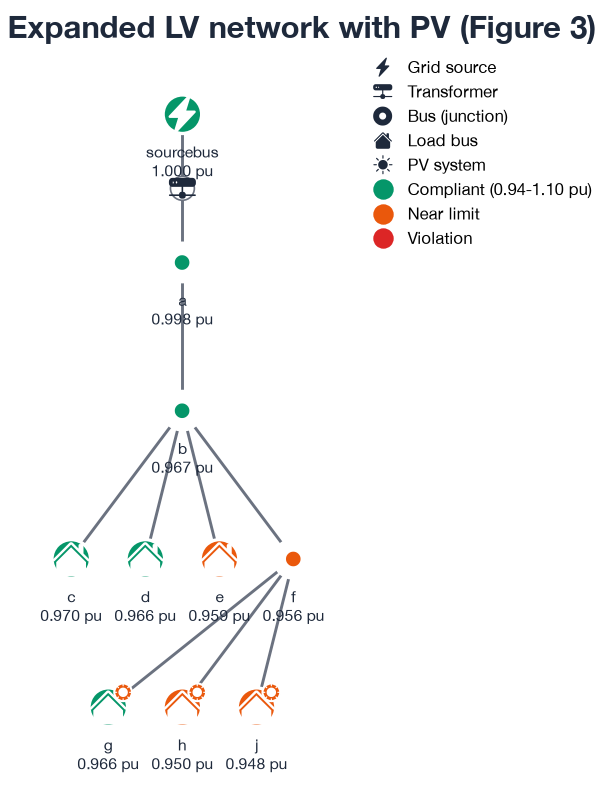

In [ ]:
pv_circuit_topology = build_expanded_lv_network(include_pv=True)
plot_topology(pv_circuit_topology, title="Expanded LV network with PV (Figure 3)")

<div style="text-align: justify;">

### **Exercise 3: Modelling a New Simple LV Network**

In this exercise, you will model a new LV network from scratch.

<font color='red'>**Note:**</font> You must follow the sequence discussed,
so that your power flow converges.

The configuration of the LV network is given in Figure 4.

<center><img style="float: middle;" src="Figure_4.png" width="60%"></center>
<center>Figure 4. New Simple LV Network</center>

Here are the characteristics of the elements:

- **`SourceBus`**: 11kV, three-phase.
- **`Transformer`**: delta/wye connection, 11kV to 0.4kV TR ratio, 250kVA
  rated capacity, 0% series resistance, 2.5pu reactance, 0% loss at rated
  power.
- **`Linecodes`**:
  - **Linecode.240sq**: 3-phase, R1=0.127, X1=0.072, R0=0.342, X0=0.089,
    units=km.
  - **Linecode.16sq**: 1-phase, R1=1.15, X1=0.083, R0=1.2, X0=0.083, units=km.
  - **Linecode.185sq**: 3-phase, R1=0.78, X1=0.042, R0=1.08, X0=0.093,
    units=km.
- **`3-phase Lines`**: Line.A_B_1 (1km, 240sq), Line.A_B_2 (1km, 240sq),
  Line.B_C (0.8km, 240sq), Line.C_D (0.6km, 240sq), Line.D_J (0.01km,
  185sq).
- **`Single-phase lines`**: Line.B_E, Line.C_F, Line.C_G, Line.D_H, each
  0.01km, linecode 16sq.
- **`Single-phase Loads`**: Load_1 (bus E), Load_2 (bus F), Load_3 (bus G),
  Load_4 (bus H), each rated voltage `(0.4 3 sqrt /)`, active power and
  power factor from Table 3, constant P+jQ model, Vminpu=0.85, Vmaxpu=1.20.
- **`Three-phase Loads`**: Load_5 (bus J), rated voltage 0.4, active power
  and power factor from Table 3, same model and limits.
- **`PV Systems`** (include only when specified): PV_1 (bus E), PV_2 (bus
  F), PV_3 (bus G), PV_4 (bus H), each single-phase, 5kVA installed, 5kW
  maximum power point, rated voltage `(0.4 3 sqrt /)`.

| Load Name | Phases | Connected bus | Demand (kW) | PF |
|:---------:|:------:|:-------------:|:------------:|:--:|
| Load_1 | 1 | E | 6 | 0.95 |
| Load_2 | 1 | F | 4 | 0.95 |
| Load_3 | 1 | G | 6 | 0.95 |
| Load_4 | 1 | H | 7 | 0.95 |
| Load_5 | 3 | J | 15 | 0.95 |

Annual load duration: peak 1750 hours, medium (75% of peak) 4380 hours,
minimum (25% of peak) 2630 hours.

**E3.1:** Calculate the total annual energy losses of the circuit in kWh.

**E3.2:** Extract the voltages (in pu) of all the houses for each loading
level. Are those voltages compliant with the statutory limits at all times?
If not, why?

Now, consider the network configuration given in Figure 5 and add the
corresponding solar PV systems.

<center><img style="float: middle;" src="Figure_5.png" width="60%"></center>
<center>Figure 5. New Simple LV Network with PV Systems</center>

**E3.3:** Calculate the total annual energy losses of the circuit in kWh.
Is this value different from the previous case (Figure 4)? If so, why?

**E3.4:** Extract the voltages (in pu) of all the houses for each loading
level. Are those voltages compliant with the statutory limits at all times?
If not, why?

</div>

<div style="text-align: justify;">

#### Solution

This is a new topology, not an extension of Figures 1-3, so
`build_new_lv_network` starts from an empty circuit rather than reusing
`build_expanded_lv_network`. Note the two parallel three-phase lines
`A_B_1`/`A_B_2` between the same two buses, exactly as specified: a real LV
design pattern for splitting current across two circuits, and a good check
that `topology_layout`'s BFS handles a repeated bus pair without crashing
(both edges get drawn, overlapping, since they connect the same two
points).

</div>

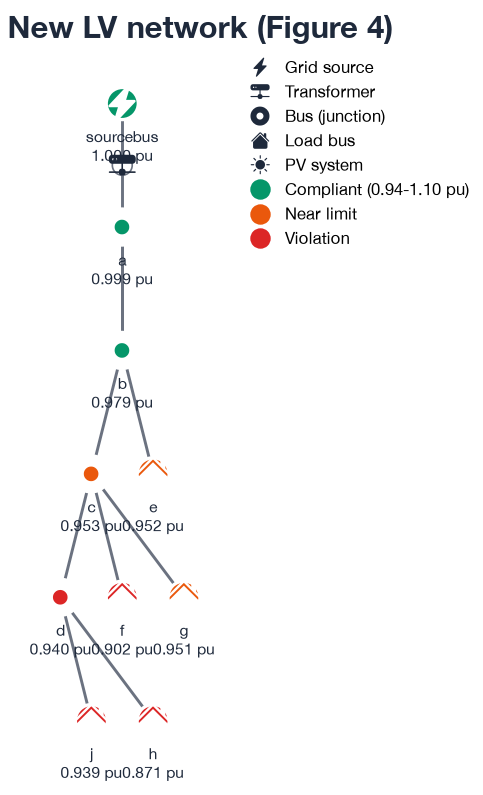

In [ ]:
def build_new_lv_network(include_pv: bool = False) -> Circuit:
    circuit = Circuit()
    circuit.command("Clear")
    circuit.command("Set DefaultBaseFrequency=50")
    circuit.command("New Circuit.New_LV_Network")
    circuit.command("Edit vsource.source bus1=sourceBus basekv=11 pu=1.0 phases=3")
    circuit.command(
        "New transformer.LVTR Buses=[sourcebus, A.1.2.3] Conns=[delta wye] "
        "KVs=[11, 0.4] KVAs=[250 250] %Rs=0.00 xhl=2.5 %loadloss=0"
    )
    circuit.command("new linecode.240sq nphases=3 R1=0.127 X1=0.072 R0=0.342 X0=0.089 units=km")
    circuit.command("new linecode.16sq nphases=1 R1=1.15 X1=0.083 R0=1.2 X0=0.083 units=km")
    circuit.command("new linecode.185sq nphases=3 R1=0.78 X1=0.042 R0=1.08 X0=0.093 units=km")

    circuit.command("new line.A_B_1 bus1=A.1.2.3 bus2=B.1.2.3 length=1 phases=3 units=km linecode=240sq")
    circuit.command("new line.A_B_2 bus1=A.1.2.3 bus2=B.1.2.3 length=1 phases=3 units=km linecode=240sq")
    circuit.command("new line.B_C bus1=B.1.2.3 bus2=C.1.2.3 length=0.8 phases=3 units=km linecode=240sq")
    circuit.command("new line.C_D bus1=C.1.2.3 bus2=D.1.2.3 length=0.6 phases=3 units=km linecode=240sq")
    circuit.command("new line.D_J bus1=D.1.2.3 bus2=J.1.2.3 length=0.01 phases=3 units=km linecode=185sq")
    circuit.command("new line.B_E bus1=B.1 bus2=E.1 length=0.01 phases=1 units=km linecode=16sq")
    circuit.command("new line.C_F bus1=C.1 bus2=F.1 length=0.01 phases=1 units=km linecode=16sq")
    circuit.command("new line.C_G bus1=C.2 bus2=G.1 length=0.01 phases=1 units=km linecode=16sq")
    circuit.command("new line.D_H bus1=D.1 bus2=H.1 length=0.01 phases=1 units=km linecode=16sq")

    circuit.command(
        "new load.Load_1 bus1=E.1 phases=1 kV=(0.4 3 sqrt /) kW=6 pf=0.95 "
        "model=1 conn=wye Vminpu=0.85 Vmaxpu=1.20 status=fixed"
    )
    circuit.command(
        "new load.Load_2 bus1=F.1 phases=1 kV=(0.4 3 sqrt /) kW=4 pf=0.95 "
        "model=1 conn=wye Vminpu=0.85 Vmaxpu=1.20 status=fixed"
    )
    circuit.command(
        "new load.Load_3 bus1=G.1 phases=1 kV=(0.4 3 sqrt /) kW=6 pf=0.95 "
        "model=1 conn=wye Vminpu=0.85 Vmaxpu=1.20 status=fixed"
    )
    circuit.command(
        "new load.Load_4 bus1=H.1 phases=1 kV=(0.4 3 sqrt /) kW=7 pf=0.95 "
        "model=1 conn=wye Vminpu=0.85 Vmaxpu=1.20 status=fixed"
    )
    circuit.command(
        "new load.Load_5 bus1=J.1.2.3 phases=3 kV=0.4 kW=15 pf=0.95 "
        "model=1 conn=wye Vminpu=0.85 Vmaxpu=1.20 status=fixed"
    )

    if include_pv:
        circuit.command("new PVSystem.PV1 bus1=E.1 phases=1 kva=5 pmpp=5 pf=1 kV=(0.4 3 sqrt /) model=1")
        circuit.command("new PVSystem.PV2 bus1=F.1 phases=1 kva=5 pmpp=5 pf=1 kV=(0.4 3 sqrt /) model=1")
        circuit.command("new PVSystem.PV3 bus1=G.1 phases=1 kva=5 pmpp=5 pf=1 kV=(0.4 3 sqrt /) model=1")
        circuit.command("new PVSystem.PV4 bus1=H.1 phases=1 kva=5 pmpp=5 pf=1 kV=(0.4 3 sqrt /) model=1")

    circuit.command("set controlmode=static")
    circuit.command("set mode=snapshot")
    circuit.command("Set VoltageBases=[11 0.4]")
    circuit.command("calcvoltagebases")
    circuit.solve()
    return circuit


new_circuit = build_new_lv_network()
plot_topology(new_circuit, title="New LV network (Figure 4)")

In [ ]:
LEVELS_TABLE_4 = [
    ("Peak", 1.0, 1750),
    ("Medium", 0.75, 4380),
    ("Minimum", 0.25, 2630),
]
new_peak_kw = {"Load_1": 6, "Load_2": 4, "Load_3": 6, "Load_4": 7, "Load_5": 15}
new_houses = ["e", "f", "g", "h", "j"]

new_voltage_df, new_annual_loss_kwh = evaluate_loading_levels(
    lambda: build_new_lv_network(include_pv=False), new_peak_kw, LEVELS_TABLE_4, new_houses
)
print(f"E3.1: total annual energy losses (Figure 4, no PV) = {new_annual_loss_kwh:.1f} kWh")

E3.1: total annual energy losses (Figure 4, no PV) = 12184.1 kWh


In [ ]:
plot_voltage_compliance(new_voltage_df, "E3.2: house voltages by loading level (Figure 4, no PV)")

<div style="text-align: justify;">

Now add the PV systems from Figure 5 and repeat both checks.

</div>

In [ ]:
new_pv_voltage_df, new_pv_annual_loss_kwh = evaluate_loading_levels(
    lambda: build_new_lv_network(include_pv=True), new_peak_kw, LEVELS_TABLE_4, new_houses
)

print(f"E3.3: total annual energy losses (Figure 5, with PV) = {new_pv_annual_loss_kwh:.1f} kWh")
print(f"Compare: without PV (E3.1) = {new_annual_loss_kwh:.1f} kWh")
print(
    "PV generation offsets part of each house's own demand before it ever reaches "
    "the feeder, so less current flows through B_C/C_D/D_J at Peak and Medium "
    "loading, and total I^2*R losses drop versus the no-PV case, even though the "
    "Minimum-loading case now pushes some power backward instead."
)

E3.3: total annual energy losses (Figure 5, with PV) = 3553.7 kWh
Compare: without PV (E3.1) = 12184.1 kWh
PV generation offsets part of each house's own demand before it ever reaches the feeder, so less current flows through B_C/C_D/D_J at Peak and Medium loading, and total I^2*R losses drop versus the no-PV case, even though the Minimum-loading case now pushes some power backward instead.


In [ ]:
plot_voltage_compliance(new_pv_voltage_df, "E3.4: house voltages by loading level (Figure 5, with PV)")

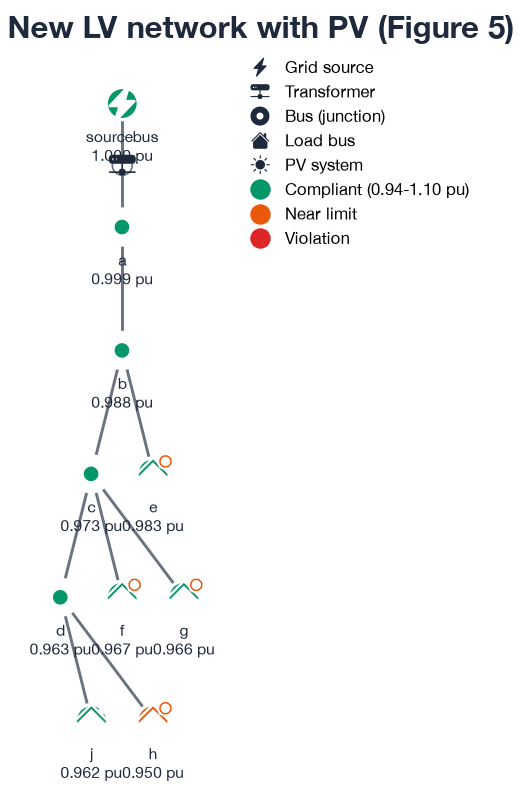

In [ ]:
new_pv_topology = build_new_lv_network(include_pv=True)
plot_topology(new_pv_topology, title="New LV network with PV (Figure 5)")